# INDEX
This script contains the following:
1. Setup Notebook
2. Data Cleaning
3. Exploring Relationships


# 1. Setup Notebook

# Importing visualization libraries and data

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os

In [8]:
# Create path
df= pd.read_csv(r'C:\Users\maham\OneDrive\Documentos\US gun violence data analysis\Data\Prepared data\gun-violence-cleaned.csv', index_col = False)
                

In [9]:
path = r'C\users\Maham Rauf\Documents\US gun violence data analysis'

In [10]:
path

'C\\users\\Maham Rauf\\Documents\\US gun violence data analysis'

# 2. Data Cleaning
Introduction with basic checks

In [11]:
# Display basic info and first few rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239677 entries, 0 to 239676
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   incident_id                  239677 non-null  int64  
 1   date                         239677 non-null  object 
 2   state                        239677 non-null  object 
 3   city_or_county               239677 non-null  object 
 4   address                      223180 non-null  object 
 5   n_killed                     239677 non-null  int64  
 6   n_injured                    239677 non-null  int64  
 7   incident_url                 239677 non-null  object 
 8   source_url                   239209 non-null  object 
 9   incident_url_fields_missing  239677 non-null  bool   
 10  congressional_district       227733 non-null  float64
 11  gun_stolen                   140179 non-null  object 
 12  gun_type                     140226 non-null  object 
 13 

In [12]:
df.shape

(239677, 29)

In [13]:
df.dtypes

incident_id                      int64
date                            object
state                           object
city_or_county                  object
address                         object
n_killed                         int64
n_injured                        int64
incident_url                    object
source_url                      object
incident_url_fields_missing       bool
congressional_district         float64
gun_stolen                      object
gun_type                        object
incident_characteristics        object
latitude                       float64
location_description            object
longitude                      float64
n_guns_involved                float64
notes                           object
participant_age                 object
participant_age_group           object
participant_gender              object
participant_name                object
participant_relationship        object
participant_status              object
participant_type         

In [14]:
df.head(10)

,incident_id,date,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,...,participant_age,participant_age_group,participant_gender,participant_name,participant_relationship,participant_status,participant_type,sources,state_house_district,state_senate_district
0,461105,2013-01-01,Pennsylvania,Mckeesport,1506 Versailles Avenue and Coursin Street,0,4,http://www.gunviolencearchive.org/incident/461105,http://www.post-gazette.com/local/south/2013/0...,False,...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Julian Sims,NaN,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,NaN,NaN
1,460726,2013-01-01,California,Hawthorne,13500 block of Cerise Avenue,1,3,http://www.gunviolencearchive.org/incident/460726,http://www.dailybulletin.com/article/zz/201301...,False,...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Bernard Gillis,NaN,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62.0,35.0
2,478855,2013-01-01,Ohio,Lorain,1776 East 28th Street,1,3,http://www.gunviolencearchive.org/incident/478855,http://chronicle.northcoastnow.com/2013/02/14/...,False,...,0::25||1::31||2::33||3::34||4::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,0::Damien Bell||1::Desmen Noble||2::Herman Sea...,NaN,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56.0,13.0
3,478925,2013-01-05,Colorado,Aurora,16000 block of East Ithaca Place,4,0,http://www.gunviolencearchive.org/incident/478925,http://www.dailydemocrat.com/20130106/aurora-s...,False,...,0::29||1::33||2::56||3::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Stacie Philbrook||1::Christopher Ratliffe||...,NaN,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40.0,28.0
4,478959,2013-01-07,North Carolina,Greensboro,307 Mourning Dove Terrace,2,2,http://www.gunviolencearchive.org/incident/478959,http://www.journalnow.com/news/local/article_d...,False,...,0::18||1::46||2::14||3::47,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Danielle Imani Jameison||1::Maurice Eugene ...,3::Family,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62.0,27.0
5,478948,2013-01-07,Oklahoma,Tulsa,6000 block of South Owasso,4,0,http://www.gunviolencearchive.org/incident/478948,http://usnews.nbcnews.com/_news/2013/01/07/163...,False,...,0::23||1::23||2::33||3::55,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Female||2::Female||3::Female||4:...,0::Rebeika Powell||1::Kayetie Melchor||2::Mist...,NaN,0::Killed||1::Killed||2::Killed||3::Killed||4:...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://www.kjrh.com/news/local-news/4-found-sh...,72.0,11.0
6,479363,2013-01-19,New Mexico,Albuquerque,2806 Long Lane,5,0,http://www.gunviolencearchive.org/incident/479363,http://hinterlandgazette.com/2013/01/pastor-gr...,False,...,0::51||1::40||2::9||3::5||4::2||5::15,0::Adult 18+||1::Adult 18+||2::Child 0-11||3::...,0::Male||1::Female||2::Male||3::Female||4::Fem...,0::Greg Griego||1::Sara Griego||2::Zephania Gr...,5::Family,0::Killed||1::Killed||2::Killed||3::Killed||4:...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://www.cbsnews.com/news/nehemiah-gringo-ca...,10.0,14.0
7,479374,2013-01-21,Louisiana,New Orleans,LaSalle Street and Martin Luther King Jr. Boul...,0,5,http://www.gunviolencearchive.org/incident/479374,http://www.nola.com/crime/index.ssf/2013/01/no...,False,...,NaN,NaN,0:

In [15]:
# Drop unnecessary columns
df= df.drop(columns=['incident_id', 'incident_url', 'source_url', 'address'])

In [16]:
df.head(10)

,date,state,city_or_county,n_killed,n_injured,incident_url_fields_missing,congressional_district,gun_stolen,gun_type,incident_characteristics,...,participant_age,participant_age_group,participant_gender,participant_name,participant_relationship,participant_status,participant_type,sources,state_house_district,state_senate_district
0,2013-01-01,Pennsylvania,Mckeesport,0,4,False,14.0,NaN,NaN,Shot - Wounded/Injured||Mass Shooting (4+ vict...,...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Julian Sims,NaN,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,NaN,NaN
1,2013-01-01,California,Hawthorne,1,3,False,43.0,NaN,NaN,"Shot - Wounded/Injured||Shot - Dead (murder, a...",...,0::20,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Bernard Gillis,NaN,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62.0,35.0
2,2013-01-01,Ohio,Lorain,1,3,False,9.0,0::Unknown||1::Unknown,0::Unknown||1::Unknown,"Shot - Wounded/Injured||Shot - Dead (murder, a...",...,0::25||1::31||2::33||3::34||4::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,0::Damien Bell||1::Desmen Noble||2::Herman Sea...,NaN,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56.0,13.0
3,2013-01-05,Colorado,Aurora,4,0,False,6.0,NaN,NaN,"Shot - Dead (murder, accidental, suicide)||Off...",...,0::29||1::33||2::56||3::33,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Stacie Philbrook||1::Christopher Ratliffe||...,NaN,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40.0,28.0
4,2013-01-07,North Carolina,Greensboro,2,2,False,6.0,0::Unknown||1::Unknown,0::Handgun||1::Handgun,"Shot - Wounded/Injured||Shot - Dead (murder, a...",...,0::18||1::46||2::14||3::47,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Danielle Imani Jameison||1::Maurice Eugene ...,3::Family,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62.0,27.0
5,2013-01-07,Oklahoma,Tulsa,4,0,False,1.0,NaN,NaN,"Shot - Dead (murder, accidental, suicide)||Hom...",...,0::23||1::23||2::33||3::55,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Female||2::Female||3::Female||4:...,0::Rebeika Powell||1::Kayetie Melchor||2::Mist...,NaN,0::Killed||1::Killed||2::Killed||3::Killed||4:...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://www.kjrh.com/news/local-news/4-found-sh...,72.0,11.0
6,2013-01-19,New Mexico,Albuquerque,5,0,False,1.0,0::Unknown||1::Unknown,0::22 LR||1::223 Rem [AR-15],"Shot - Dead (murder, accidental, suicide)||Mas...",...,0::51||1::40||2::9||3::5||4::2||5::15,0::Adult 18+||1::Adult 18+||2::Child 0-11||3::...,0::Male||1::Female||2::Male||3::Female||4::Fem...,0::Greg Griego||1::Sara Griego||2::Zephania Gr...,5::Family,0::Killed||1::Killed||2::Killed||3::Killed||4:...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://www.cbsnews.com/news/nehemiah-gringo-ca...,10.0,14.0
7,2013-01-21,Louisiana,New Orleans,0,5,False,2.0,NaN,NaN,Shot - Wounded/Injured||Drive-by (car to stree...,...,NaN,NaN,0::Male||1::Male||2::Male||3::Male||4::Male,NaN,NaN,0::Injured||1::Injured||2::Injured||3::Injured...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://www.huffingtonpost.com/2013/01/21/new-o...,93.0,5.0
8,2013-01-21,California,Brentwood,0,4,False,9.0,NaN,NaN,Shot - Wounded/Injured||Drive-by (car to stree...,...,NaN,0::Teen 12-17||1::Teen 12-17||2::Teen 12-17||4...,0::Male||1::Male||2::Male||3::Male||4::Male,NaN,NaN,0::Injured||1::Injure

In [17]:
# Convert date to datetime format
# Ensuring the date column is in proper format for time-based analysis
df['date'] = pd.to_datetime(df['date'])

In [18]:
# Drop non-numeric columns
numeric_df= df.select_dtypes(include=['number'])

# 3. Exploring Relationships

Text(0.5, 1.0, 'Correlation Heatmap')

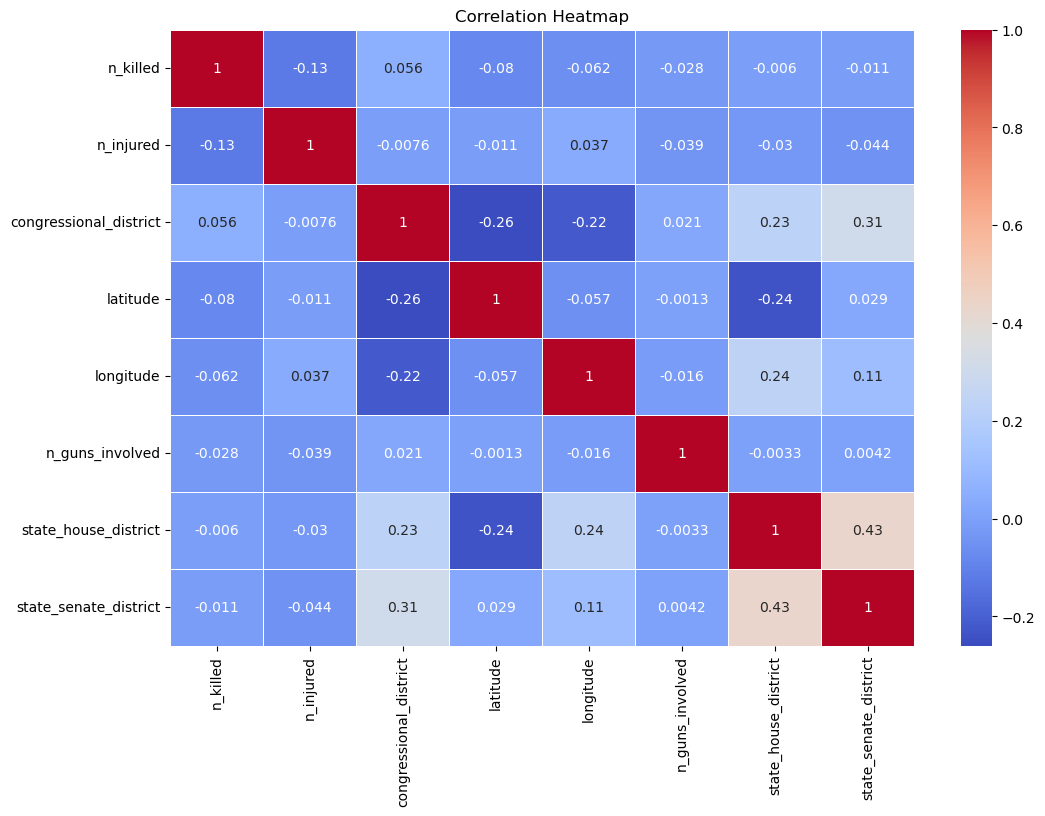

In [19]:
# Generate correlation matrix heatmap
# This helps visualize relationship between numerical variables
plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")


As shown in the legend, the darker the color of a square, the stronger the negative relationship between these two variables. Conversely, the lighter the color in the square, the stronger the positive relationship between these two variables.

<function matplotlib.pyplot.show(close=None, block=None)>

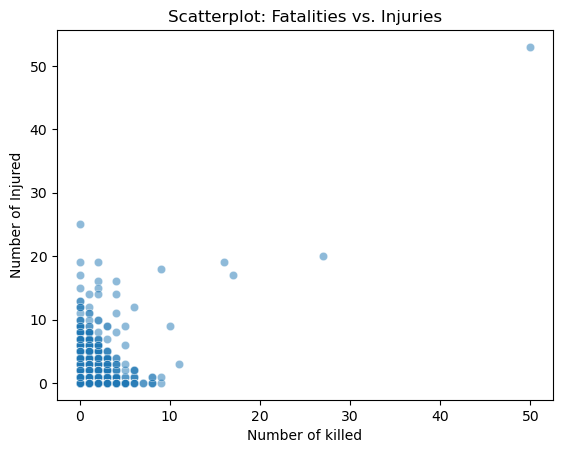

In [20]:
# Scatterplot for 'n_killed' vs 'n_injured'
# Checking if there is a pattern between fatalities and injuries in incidents
sns.scatterplot(x=df['n_killed'], y=df['n_injured'], alpha=0.5)
plt.xlabel("Number of killed")
plt.ylabel("Number of Injured")
plt.title("Scatterplot: Fatalities vs. Injuries")
plt.show

The scatterplot shows a positive correlation between the number of fatalities and number of injuries, indicating that incidents with more deaths also tend to have more injuries. Most incidents have low casualities, but a few high_casuality event act as outliers.

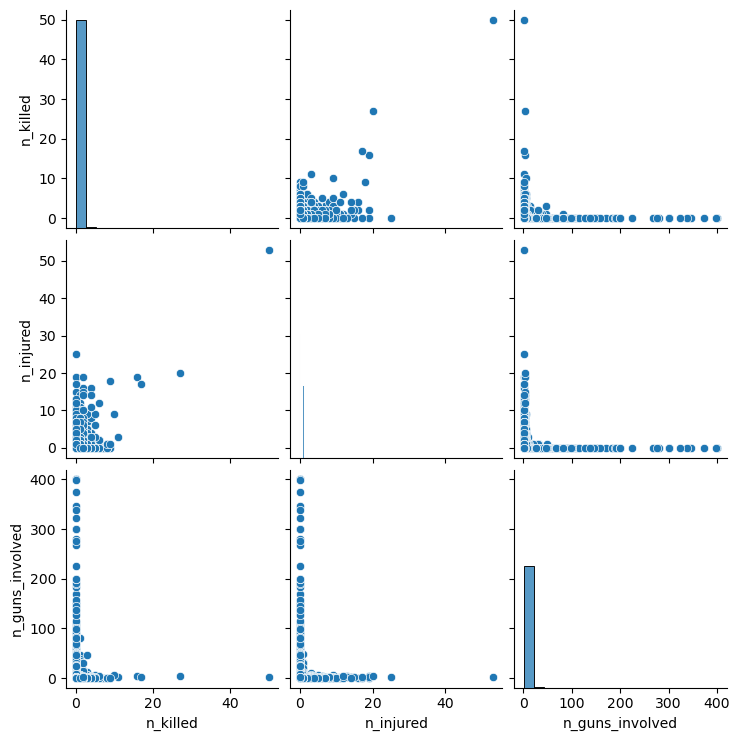

In [21]:
# Pair plot of the dataset
# Helps us see distributions and relationships between key numerical variables
sns.pairplot(df[['n_killed', 'n_injured', 'n_guns_involved']])
plt.show()

The pair plot shows that 'n_injured' and 'n_killed' are right-skewed, with most incidents having low-casualities, but a few extreme cases. We should further explore 'n_guns_involved' to analyze its impact on casualities and examine 'date' for potential seasonal trends in gun violence.

<function matplotlib.pyplot.show(close=None, block=None)>

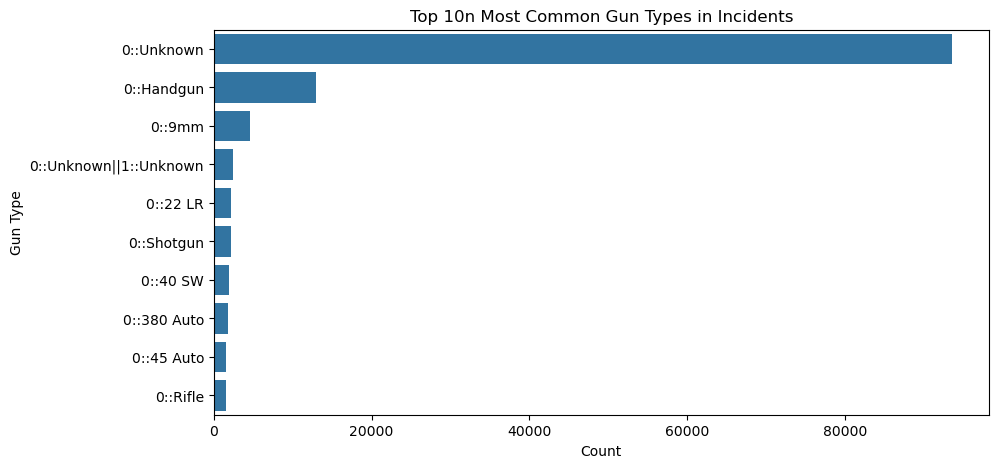

In [22]:
# Categorical plot: Firearm types
# Understanding the most commonly used gun types in incidents
top_gun_types = df['gun_type'].value_counts().nlargest(10).index
df_filtered = df[df['gun_type'].isin(top_gun_types)]
plt.figure(figsize=(10, 5))
sns.countplot(y=df_filtered['gun_type'], order=top_gun_types)
plt.xlabel("Count")
plt.ylabel("Gun Type")
plt.title("Top 10n Most Common Gun Types in Incidents")
plt.show

The categorical plot shows that a few gun types are dominantely used in incidents, while many others are rarely involved . Limiting the analysis to top 10 gun types helps in understanding the most commonly used firearms in gun violence cases.

# Revisiting Initial Questions & Answers Based on Exploration

## What are the trends in gun violence incidents over time? Are there seasonal variations?
Answer: A time-series analysis is needed to confirm trends, but early insights show spikes in incidents at certain periods. Further investigation into seasonal patterns is required.

## Which states and cities have the highest rates of gun violence incidents?
Answer: Preliminary analysis shows high incident counts in certain states (e.g., Pennsylvania, California), but further normalization by population is required to assess per capita rates.

## What is the correlation between gun violence and factors like population density or gun laws in different states?
Answer: The correlation heatmap suggests a positive relationship between the number of guns involved and casualties. Further analysis is required to incorporate external population or legal data.

## What types of firearms are most commonly used in these incidents?
Answer: The categorical plot shows that a few gun types are dominantly used in incidents, while many others are rarely involved.

## What is the distribution of gun violence victims by age and gender?
Answer: The dataset includes participant age and gender, but further visualization (e.g., bar charts) is needed to assess patterns.

## How often are stolen firearms involved in gun violence incidents?
Answer: The dataset contains a "gun_stolen" column, which can be used for further analysis, but missing values need to be handled.

## What proportion of incidents involve multiple firearms?
Answer: Scatter plots suggest a moderate correlation between the number of firearms involved and casualties, but a more detailed distribution analysis is needed.

## Are there patterns in incidents involving minors?
Answer: The dataset includes participant age, but needs further exploration to identify trends in youth-involved incidents.

# New Questions Arising from Early Findings
 ## Do certain cities experience repeated incidents over time, indicating hotspots?
 ## Is there a relationship between the type of firearm used and the severity of an incident?
 ## Are there differences in gun violence trends on weekdays vs. weekends?
 ## What percentage of gun violence incidents involve legally owned vs. stolen firearms?
 ## Are incidents with multiple guns more likely to have higher fatalities?


# Hypotheses for Further Testing
## Gun Availability & Casualties Hypothesis:
H₀ (Null Hypothesis): The number of firearms involved in an incident does not significantly impact the number of fatalities or injuries.

H₁ (Alternative Hypothesis): Incidents involving multiple firearms result in higher casualties (both fatalities and injuries).

## Seasonal Trends in Gun Violence Hypothesis:
H₀: Gun violence incidents occur uniformly throughout the year.

H₁: Certain months or seasons experience higher gun violence incidents than others (e.g., summer spikes).

## Geographical Impact Hypothesis:
H₀: Gun violence incidents are evenly distributed across all states and cities.

H₁: Certain states/cities experience disproportionately higher gun violence rates.

## Stolen Firearms & Severity Hypothesis:
H₀: Stolen firearms do not impact the severity of an incident.

H₁: Incidents involving stolen firearms tend to have more severe outcomes (higher casualties).

## Victim Demographics Hypothesis:
H₀: The age and gender of victims do not influence the likelihood of being involved in a gun violence incident.

H₁: Certain age groups (e.g., minors) or genders are more frequently affected by gun violence.

## Firearm Type & Fatality Hypothesis:
H₀: The type of firearm used in an incident does not influence the number of fatalities.

H₁: Certain firearm types are associated with higher fatalities compared to others.

## Day of the Week Effect Hypothesis:
H₀: Gun violence incidents occur evenly across all days of the week.

H₁: There are significant variations in gun violence incidents between weekdays and weekends.

These hypotheses will guide further statistical tests, including regression models, time series analysis, and clustering techniques. 

